# A/B Testing

A/B testing, also known as **split testing**, is a widely used experimental method in **marketing, product development, and data science** to compare two or more versions of a feature, product, or user experience. The primary objective is to determine which variation performs better based on a predefined success metric.

At its core, A/B testing relies on **causal inference through hypothesis testing**. Users are randomly assigned to different groups, where each group is exposed to a different version (typically **Version A** and **Version B**) of the variable being tested. The outcomes are then measured and statistically compared to determine whether any observed differences are significant or simply due to random chance.

Random assignment plays a crucial role in minimizing bias and ensuring that the experiment produces reliable and statistically valid results. This enables organizations to make **data-driven decisions** rather than relying on intuition or assumptions.

### Why is A/B Testing Important?

A/B testing helps organizations:

- 📈 Optimize website and application performance.
- 🎯 Improve marketing campaigns and conversion rates.
- 🛍️ Evaluate new product features before full deployment.
- 😊 Enhance user experience through evidence-based decisions.
- 📊 Support continuous improvement using statistical analysis.

In this notebook, we will apply the principles of **A/B testing** to analyze experimental data, perform hypothesis testing, and determine whether the treatment group produces a statistically significant improvement over the control group.

## 📈 A/B Testing on Continuous Outcomes

A/B testing on **continuous outcomes** 📊 involves evaluating the impact of changes in experimental conditions on variables that assume a **continuous range of values**. This method is commonly applied in scenarios where numerical metrics, such as **response time** ⏱️ or **revenue** 💰, are crucial performance indicators.

For instance:

- 🛒 Consider an **e-commerce platform** implementing an A/B test to assess the effect of different checkout processes on the **average purchase amount**.
- 💻 A **software company** testing variations in **user interface design** to measure the impact on **user engagement time**.

In both cases, A/B testing on continuous outcomes provides a robust framework for **data-driven decision-making** 📈, allowing organizations to refine strategies, optimize performance 🚀, and make informed decisions based on quantitative measurements.

## 🎯 1. Define the Problem

Facebook has recently developed a new bidding system for its advertisements called **Average Bidding** (**Test Group**) 🧪, alongside the classic **Maximum Bidding** (**Control Group**) 🎯. The bidding strategy determines which advertisement will be presented to the user based on the amount the advertiser is willing to pay.

- 💰 **Maximum Bidding (Control Group):** The advertiser specifies the **maximum amount** they are willing to pay for each impression.
- 📊 **Average Bidding (Test Group):** The advertiser specifies the **average amount** they are willing to pay for each impression.

The dataset analyzed in this notebook contains the results of these two bidding strategies over a period of **40 days** 📅. The objective is to determine whether the **Average Bidding** strategy leads to better performance than the traditional **Maximum Bidding** strategy in terms of earnings.

In [173]:
import pandas as pd
df_control = pd.read_csv("/kaggle/input/datasets/furth3r/facebook-ab-test-of-bidding-feature/ab_test/control_group.csv")
df_test = pd.read_csv("/kaggle/input/datasets/furth3r/facebook-ab-test-of-bidding-feature/ab_test/test_group.csv")

df_control.info()
display(df_control.head())
print("-"*50)
df_test.info()
display(df_test.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Impression  40 non-null     int64
 1   Click       40 non-null     int64
 2   Purchase    40 non-null     int64
 3   Earning     40 non-null     int64
dtypes: int64(4)
memory usage: 1.4 KB


,Impression,Click,Purchase,Earning
0,82529,6090,665,2311
1,98050,3383,315,1743
2,82696,4168,458,1798
3,109914,4911,487,1696
4,108458,5988,441,1544


--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Impression  40 non-null     int64
 1   Click       40 non-null     int64
 2   Purchase    40 non-null     int64
 3   Earning     40 non-null     int64
dtypes: int64(4)
memory usage: 1.4 KB


,Impression,Click,Purchase,Earning
0,120104,3217,702,1940
1,134776,3635,834,2929
2,107807,3057,423,2526
3,116445,4650,429,2281
4,145083,5201,750,2782


## 🧪 2. Define the Null and Alternative Hypotheses

In **statistical hypothesis testing** 📊, the **null hypothesis ($H_0$)** assumes that there is **no significant effect, relationship, or difference** between the variables being studied. It serves as the baseline assumption for statistical analysis.

On the other hand, the **alternative hypothesis ($H_1$ or $H_a$)** suggests that there **is** a statistically significant effect, relationship, or difference. Researchers use hypothesis testing to evaluate the evidence against the null hypothesis and determine whether the observed data provides sufficient support to reject it in favor of the alternative hypothesis.

The interplay between these hypotheses forms the foundation for drawing conclusions in statistical analyses.

### 📌 Hypotheses for This Problem

Since the objective is to determine whether the **Average Bidding** strategy performs differently from the **Maximum Bidding** strategy, we define the hypotheses as:

- **Null Hypothesis ($H_0$):** There is **no statistically significant difference** in the average earnings between the **Maximum Bidding** (Control Group) and **Average Bidding** (Test Group).
- **Alternative Hypothesis ($H_1$):** There **is a statistically significant difference** in the average earnings between the **Maximum Bidding** (Control Group) and **Average Bidding** (Test Group).

### 📌 Hypotheses

Let:

- $\mu_{\text{control}}$ = Mean earnings of the **Maximum Bidding** (Control Group)
- $\mu_{\text{test}}$ = Mean earnings of the **Average Bidding** (Test Group)

Since the objective is to determine whether the new **Average Bidding** strategy outperforms the traditional **Maximum Bidding** strategy, we formulate a **one-tailed hypothesis test**:

- **Null Hypothesis ($H_0$):** $\mu_{\text{control}} \geq \mu_{\text{test}}$
- **Alternative Hypothesis ($H_1$):** $\mu_{\text{control}} < \mu_{\text{test}}$

In other words, we test whether the **Average Bidding** strategy generates significantly higher average earnings than the **Maximum Bidding** strategy.

## ⚖️ 3. Set the Probability of Type I and Type II Errors

In statistical hypothesis testing, the **Type I error** ($\alpha$) represents the probability of **incorrectly rejecting a true null hypothesis**. It is commonly referred to as the **significance level** of the test and defines the threshold for determining whether the observed results are statistically significant.

The **Type II error** ($\beta$) is the probability of **failing to reject a false null hypothesis**. The **statistical power** of a test, defined as $(1-\beta)$, measures the probability of correctly detecting a true effect when one actually exists.

Choosing appropriate values for $\alpha$ and $\beta$ involves a trade-off. A lower significance level decreases the risk of a **Type I error** but may increase the likelihood of a **Type II error**. Therefore, these values should be selected carefully based on the objectives of the experiment.

### 📌 Significance Level for This Analysis

For this A/B test, we use the following values:

- **Type I error ($\alpha$):** **0.05** (5%)
- **Type II error ($\beta$):** **0.20** (20%)
- **Statistical Power ($1-\beta$):** **0.80** (80%)

These are the standard values commonly adopted in A/B testing and experimental studies.

## 🗂️ 4. Check and Prepare the Data

Before performing the A/B test, it is essential to ensure that the dataset is **clean, accurate, and suitable for statistical analysis**. Data preprocessing helps eliminate potential sources of bias and improves the reliability of the results.

The data preparation process includes:

- 🔍 Checking for **missing values**.
- ⚠️ Identifying **mismatched or inconsistent** data.
- 📑 Detecting and removing **duplicate records**.
- 📊 Identifying and handling **outliers** when appropriate.

Performing these data quality checks ensures that the subsequent statistical analysis is based on reliable data, leading to more accurate conclusions and informed decision-making.

In [174]:
import pandas as pd

# Report on count and percentage of missing values in each column
missing_values_report = pd.DataFrame({
    'Column': df_control.columns,
    'Missing Values': df_control.isnull().sum(),
    'Percentage Missing': df_control.isnull().mean() * 100
})

# Display the missing values report
print("Missing Values Report:")
display(missing_values_report)

Missing Values Report:


,Column,Missing Values,Percentage Missing
Impression,Impression,0,0.0
Click,Click,0,0.0
Purchase,Purchase,0,0.0
Earning,Earning,0,0.0


In [175]:
import pandas as pd

# Report on count and percentage of missing values in each column
missing_values_report = pd.DataFrame({
    'Column': df_test.columns,
    'Missing Values': df_test.isnull().sum(),
    'Percentage Missing': df_test.isnull().mean() * 100
})

# Display the missing values report
print("Missing Values Report:")
display(missing_values_report)

Missing Values Report:


,Column,Missing Values,Percentage Missing
Impression,Impression,0,0.0
Click,Click,0,0.0
Purchase,Purchase,0,0.0
Earning,Earning,0,0.0


no missing values are obsereved 

In [176]:
control_dup = df_control.duplicated().sum()
test_dup = df_test.duplicated().sum()

print(f'number of duplicated rows for control group : {control_dup} \n number of duplicated rows for test group : {test_dup}')

number of duplicated rows for control group : 0 
 number of duplicated rows for test group : 0


In [177]:
concatenated_control = pd.concat([
    df_control.describe().T,
    df_control.skew().rename('skewness'),
    df_control.kurtosis().rename('kurtosis')
], axis=1)

print(concatenated_control)

concatenated_test = pd.concat([
    df_test.describe().T,
    df_test.skew().rename('skewness'),
    df_test.kurtosis().rename('kurtosis')
], axis=1)

print(concatenated_test)



            count        mean           std      min       25%      50%  \
Impression   40.0  101711.450  20302.122984  45476.0  85726.75  99790.5   
Click        40.0    5100.625   1329.957772   2190.0   4124.25   5001.5   
Purchase     40.0     550.900    134.110517    267.0    470.50    531.5   
Earning      40.0    1908.575    302.868329   1254.0   1685.75   1975.0   

                 75%       max  skewness  kurtosis  
Impression  115212.5  147539.0 -0.001687  0.410967  
Click         5923.5    7959.0  0.179859 -0.436239  
Purchase       638.0     802.0 -0.026949 -0.571140  
Earning       2120.0    2497.0 -0.275640 -0.382968  
            count        mean           std      min        25%       50%  \
Impression   40.0  120512.425  18807.466616  79034.0  112692.25  119291.5   
Click        40.0    3967.550    923.071766   1837.0    3376.50    3931.5   
Purchase     40.0     582.050    161.175164    312.0     444.75     551.0   
Earning      40.0    2514.925    282.707912   1940.

### 📊 Initial Observations

The descriptive statistics show that the **Test Group (Average Bidding)** achieved higher average **Impressions**, **Purchases**, and **Earnings** compared to the **Control Group (Maximum Bidding)**, while the **Control Group** generated a higher average number of **Clicks**.

Additionally, the skewness values are close to zero and the kurtosis values are close to zero or slightly negative for all variables in both groups, suggesting that the distributions are approximately symmetric with no evidence of extreme outliers. This indicates that the data is generally well-behaved and suitable for further statistical analysis.

## 📏 5. Calculate the Sample Size

Calculating the **sample size** is an essential step in designing an A/B test, as it determines the minimum number of observations required to detect a meaningful difference between two independent groups with a specified level of confidence and statistical power.

The sample size depends on several factors, including:

- 📊 The significance level ($\alpha$).
- ⚡ The statistical power ($1-\beta$).
- 📈 The expected variability in the data.
- 🎯 The minimum detectable effect (effect size).

A properly calculated sample size ensures that the experiment has sufficient power to detect a true difference while minimizing the risks of incorrect conclusions.

### 📌 Assumptions for This Analysis

For this example, we assume:

- **Significance level ($\alpha$):** 0.05
- **Statistical power ($1-\beta$):** 0.80
- **Minimum detectable difference:** **200** units between the group means.

## Sample Size Formula (A/B Test – Difference in Means)

$$
n = \frac{2\sigma^2 (z_{1-\alpha/2} + z_{1-\beta})^2}{\Delta^2}
$$

## Definitions

- $\sigma^2$: pooled variance of the metric (control + test groups)  
- $\Delta$: minimum detectable effect size (MDE)  
- $\alpha$: significance level (commonly 0.05)  
- $\beta$: Type II error rate (commonly 0.2 for 80% power)  
- $z_{1-\alpha/2}$: Z critical value for two-sided test (≈ 1.96 for 95%)  
- $z_{1-\beta}$: Z value for statistical power (≈ 0.84 for 80%)  

## Interpretation

This formula calculates the required sample size per group in an A/B test to detect a difference in means under:

- Equal-sized groups  
- Equal variance assumption  
- Normal approximation  
- Specified significance level and power  

In [178]:
import pandas as pd
from scipy.stats import norm
alpha = 0.05
beta = 0.2
Z = (norm.ppf(1-(alpha/2), loc=0, scale=1) + norm.ppf(1-beta, loc=0, scale=1))**2
var = pd.concat([df_control['Earning'],df_test['Earning']]).var()
expected_effect_size = 200

sample_size = (Z*2*var)/(expected_effect_size**2)

print(sample_size.astype('int'))


69


## ⚠️ Impact of Insufficient Sample Size (with Distribution Consideration)

The required sample size for this A/B test is **69 observations per group**, while the available dataset contains only **40 observations per group**. This indicates that the experiment is **underpowered** relative to the ideal design.

### 📊 Distribution Assumption

Before selecting the statistical test and interpreting sample size requirements, we assess the distribution of the data. Based on the **skewness and kurtosis values (close to 0)** across all variables, the data can be considered approximately **normally distributed**.

This supports the use of **parametric tests (e.g., t-test)** and justifies the sample size formula based on normality assumptions.

---

### 📉 What insufficient sample size means

Since the sample size is smaller than required:

- ⚠️ The test has **reduced statistical power**
- 📊 There is an increased risk of **Type II error (β)**  
  → meaning we may **fail to detect a real difference**
- 📉 The estimated effect becomes less stable due to higher sampling variability

---

### 🧠 Interaction between normality and sample size

- Because the data is **approximately normal**, the statistical test remains valid even with small samples.
- However, with only **40 observations instead of 69**, the **Central Limit Theorem effect is weaker**, meaning:
  - estimates are more sensitive to randomness  
  - confidence intervals become wider  
  - detection of true effects becomes harder  

---

### 📌 How to interpret results

- ❗ **If NOT statistically significant:**  
  This may be due to **insufficient sample size (underpowered test)** rather than absence of a true effect.

- ⚠️ **If statistically significant:**  
  The result is still meaningful, but should be interpreted with **moderate caution**, since small samples increase variability and reduce result stability.


### 🎯 Conclusion

The data is approximately normally distributed, so using a parametric test is appropriate. However, because the sample size is smaller than required, the test has lower statistical power, making a **non-significant result less conclusive**. In other words, failing to detect a significant difference may be due to **insufficient sample size rather than the absence of a true effect**.

/tmp/ipykernel_58/3933310076.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


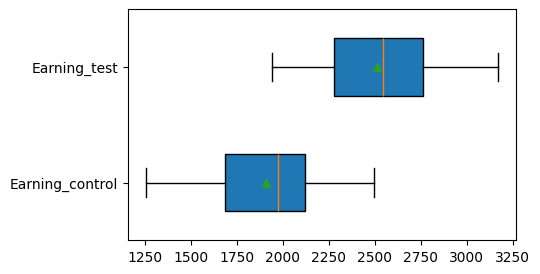

In [179]:


import matplotlib.pyplot as plt

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5, 3))

ax.boxplot(
    x=[df_control['Earning'],df_test['Earning']],         # Data to be plotted
    vert=False,                 # Whether to create a vertical boxplot (True) or horizontal (False)
    patch_artist=True,          # If True, fill the box with color
    widths=0.5,                 # Width of the boxes
    sym='r|',                   # Symbol for outliers
    labels=['Earning_control','Earning_test'],     # Labels for each boxplot
    showmeans=True,             # If True, display mean point
    showfliers=True,            # If True, display outliers

)

plt.show()



### 📌 Initial Observation

The **Test Group** has a higher average **Earning** than the **Control Group**. However, this observed difference alone is not sufficient to conclude that the new bidding strategy performs better. We must determine whether the difference is **statistically significant** through hypothesis testing.

## 📊 Test the Equality of Means Hypothesis

In **A/B testing**, comparing two independent means often involves the application of an **independent samples t-test**. This statistical method assesses whether there is a significant difference between the means of two groups, typically a **Control Group (A)** and a **Treatment Group (B)**.

The t-test assumes that the data in both groups are **normally distributed**, and it is particularly robust when sample sizes are relatively large.

An important consideration in the independent samples t-test is the assumption regarding the **equality of variances** between the two groups. The test can be applied under the assumption of **equal variances (homogeneity of variances)** or **unequal variances**, and the choice between these options impacts the interpretation of the results.

Therefore, when performing an independent samples t-test in the context of A/B testing, researchers must carefully consider and, if needed, test the assumption of **equality of variances** to ensure the validity and reliability of their statistical analysis.

## 📊 Choosing the Statistical Test

Different metrics require different statistical tests based on the type of data they represent.

- **Independent Samples t-test:** Used for **continuous metrics** to compare the average values between the Test and Control groups.
  - Revenue
  - Revenue per Impression
  - Revenue per Click
  - Average Order Value (AOV)

- **Two-Proportion z-test:** Used for **rate-based metrics** because they represent the probability of an event occurring.
  - CTR (Clicks / Impressions)
  - Conversion Rate (Purchases / Clicks)
  - Purchase Rate (Purchases / Impressions)

Since our dataset is aggregated by day, we also performed t-tests on the rate-based metrics. The proportion z-tests were included as a validation to ensure the conclusions were consistent.

In [180]:
import pandas as pd
from scipy.stats import levene
from scipy.stats import ttest_ind

mean_control = df_control['Earning'].mean()
mean_test = df_test['Earning'].mean()

print("mean_control=", mean_control)
print("mean_test=",mean_test)

# Perform two-sample t-test for each level of 'pathsize_cat'
groupC = df_control['Earning']
groupT = df_test['Earning']
    
# Perform Levene's test for homogeneity of variances
statistic, p_value_L = levene(groupC, groupT)

if  p_value_L > 0.05:

    t_statistic, p_value = ttest_ind(groupC, groupT,alternative="less" ,equal_var=True)

    print("t-statistic:", t_statistic)
    print("p-value:", p_value)

else:
        
    t_statistic, p_value = ttest_ind(groupC, groupT,alternative="less", equal_var=False)

    print("t-statistic:", t_statistic)
    print("p-value:", p_value)    
    
# Determine significance
alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis: There is a significant difference between the means.")
else:
    print("Fail to reject the null hypothesis: There is no significant difference between the means.")
print("\n")

mean_control= 1908.575
mean_test= 2514.925
t-statistic: -9.256092651165002
p-value: 1.720180077421263e-14
Reject the null hypothesis: There is a significant difference between the means.




## 📌 Conclusion

The **Test Group** achieved a higher average earning (**2514.93**) than the **Control Group** (**1908.58**).

The independent samples t-test produced a **t-statistic of -9.256** with a **p-value of 1.72 × 10⁻¹⁴**, which is far below the significance level of **0.05**.

Therefore, we **reject the null hypothesis ($H_0$)** and conclude that there is **strong statistical evidence** that the **Average Bidding** strategy generates higher average earnings than the **Maximum Bidding** strategy.

Although the experiment is slightly **underpowered** due to the limited sample size, the extremely small p-value provides strong evidence that the observed difference is unlikely to have occurred by chance.

## 📋 Engineered Features

To better evaluate the performance of the two bidding strategies, we created several derived metrics that measure efficiency at different stages of the marketing funnel:

- **CTR (Click-Through Rate):** Percentage of impressions that resulted in clicks.
- **Conversion Rate:** Percentage of clicks that resulted in purchases.
- **Purchase Rate:** Percentage of impressions that resulted in purchases.
- **Revenue per Impression:** Average revenue generated from each impression.
- **Revenue per Click:** Average revenue generated from each click.
- **AOV (Average Order Value):** Average revenue generated per purchase.

These features provide more informative performance metrics than the raw counts alone and will be used in the subsequent hypothesis tests.

In [181]:
# Click-Through Rate (CTR)
df_control["CTR"] = df_control["Click"] / df_control["Impression"]
df_test["CTR"] = df_test["Click"] / df_test["Impression"]

# Conversion Rate (CVR)
df_control["Conversion_Rate"] = df_control["Purchase"] / df_control["Click"]
df_test["Conversion_Rate"] = df_test["Purchase"] / df_test["Click"]

# Purchase Rate
df_control["Purchase_Rate"] = df_control["Purchase"] / df_control["Impression"]
df_test["Purchase_Rate"] = df_test["Purchase"] / df_test["Impression"]

# Revenue per Impression (RPI)
df_control["Revenue_per_Impression"] = df_control["Earning"] / df_control["Impression"]
df_test["Revenue_per_Impression"] = df_test["Earning"] / df_test["Impression"]

# Revenue per Click (RPC)
df_control["Revenue_per_Click"] = df_control["Earning"] / df_control["Click"]
df_test["Revenue_per_Click"] = df_test["Earning"] / df_test["Click"]

# Average Order Value (AOV)
df_control["AOV"] = df_control["Earning"] / df_control["Purchase"]
df_test["AOV"] = df_test["Earning"] / df_test["Purchase"]
print("new control df :")
display(df_control.head())
print("new test df :")
display(df_test.head())

new control df :


,Impression,Click,Purchase,Earning,CTR,Conversion_Rate,Purchase_Rate,Revenue_per_Impression,Revenue_per_Click,AOV
0,82529,6090,665,2311,0.073792,0.109195,0.008058,0.028002,0.379475,3.475188
1,98050,3383,315,1743,0.034503,0.093113,0.003213,0.017777,0.515223,5.533333
2,82696,4168,458,1798,0.050401,0.109885,0.005538,0.021742,0.431382,3.925764
3,109914,4911,487,1696,0.044680,0.099165,0.004431,0.015430,0.345347,3.482546
4,108458,5988,441,1544,0.055210,0.073647,0.004066,0.014236,0.257849,3.501134


new test df :


,Impression,Click,Purchase,Earning,CTR,Conversion_Rate,Purchase_Rate,Revenue_per_Impression,Revenue_per_Click,AOV
0,120104,3217,702,1940,0.026785,0.218216,0.005845,0.016153,0.603046,2.763533
1,134776,3635,834,2929,0.026971,0.229436,0.006188,0.021732,0.805777,3.511990
2,107807,3057,423,2526,0.028356,0.138371,0.003924,0.023431,0.826300,5.971631
3,116445,4650,429,2281,0.039933,0.092258,0.003684,0.019589,0.490538,5.317016
4,145083,5201,750,2782,0.035848,0.144203,0.005169,0.019175,0.534897,3.709333


In [182]:
import pandas as pd
from scipy.stats import levene
from scipy.stats import ttest_ind

mean_control = df_control['CTR'].mean()
mean_test = df_test['CTR'].mean()

print("mean_control =", mean_control)
print("mean_test =", mean_test)

groupC = df_control['CTR']
groupT = df_test['CTR']

# Perform Levene's test for homogeneity of variances
statistic, p_value_L = levene(groupC, groupT)

if p_value_L > 0.05:

    t_statistic, p_value = ttest_ind(
        groupT,
        groupC,
        alternative="greater",
        equal_var=True
    )

else:

    t_statistic, p_value = ttest_ind(
        groupT,
        groupC,
        alternative="greater",
        equal_var=False
    )

print("t-statistic:", t_statistic)
print("p-value:", p_value)

# Determine significance
alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis: The Test group has a significantly higher CTR.")
else:
    print("Fail to reject the null hypothesis: There is insufficient evidence that the Test group has a higher CTR.")

print("\n")

mean_control = 0.05361771682371008
mean_test = 0.03417596901675688
t-statistic: -4.437840725333371
p-value: 0.9999788873317836
Fail to reject the null hypothesis: There is insufficient evidence that the Test group has a higher CTR.




In [183]:
from statsmodels.stats.proportion import proportions_ztest

count = [
    df_test["Click"].sum(),
    df_control["Click"].sum()
]

nobs = [
    df_test["Impression"].sum(),
    df_control["Impression"].sum()
]

stat, p_value = proportions_ztest(count, nobs, alternative='larger')

print("CTR z-statistic:", stat)
print("CTR p-value:", p_value)

if p_value < 0.05:
    print("Reject H0: Test group has higher CTR")
else:
    print("Fail to reject H0")

CTR z-statistic: -129.3283262976726
CTR p-value: 1.0
Fail to reject H0


## 📊 CTR Hypothesis Testing Results

### 🧪 t-test for CTR

- Mean CTR (Control): 0.0536  
- Mean CTR (Test): 0.0342  
- t-statistic: -4.4378  
- p-value: 0.99998  

### 📌 Conclusion (t-test)

We fail to reject the null hypothesis.  
There is insufficient evidence that the Test group has a higher CTR than the Control group.

---

### 🧪 Proportion Test for CTR

- z-statistic: -129.33  
- p-value: 1.0  

### 📌 Conclusion (proportion test)

We fail to reject the null hypothesis.  
There is no statistical evidence that the Test group has a higher CTR than the Control group.

---

### 🧠 Final Insight

Both the t-test and proportion test agree that the Test group does not improve CTR compared to the Control group.  
In fact, the Control group shows a higher average CTR, suggesting that the new bidding strategy does not improve user click behavior.

In [184]:
from scipy.stats import levene, ttest_ind

test = df_test["Conversion_Rate"]
control = df_control["Conversion_Rate"]

print("mean_test =", test.mean())
print("mean_control =", control.mean())

# variance check
stat, p_levene = levene(test, control)

if p_levene > 0.05:
    t_stat, p_value = ttest_ind(test, control,
                               equal_var=True,
                               alternative="greater")
else:
    t_stat, p_value = ttest_ind(test, control,
                               equal_var=False,
                               alternative="greater")

print("t-statistic:", t_stat)
print("p-value:", p_value)

alpha = 0.05

if p_value < alpha:
    print("Reject H0: Test group has significantly higher Conversion Rate")
else:
    print("Fail to reject H0: No evidence that Test group is better in Conversion Rate")

mean_test = 0.156550878774025
mean_control = 0.11592362548153431
t-statistic: 3.1373827215830916
p-value: 0.0012026890736681092
Reject H0: Test group has significantly higher Conversion Rate


In [192]:
from statsmodels.stats.proportion import proportions_ztest

count = [
    df_test["Purchase"].sum(),
    df_control["Purchase"].sum()
]

nobs = [
    df_test["Click"].sum(),
    df_control["Click"].sum()
]

stat, p_value = proportions_ztest(count, nobs, alternative='larger')

print("CTR z-statistic:", stat)
print("CTR p-value:", p_value)

if p_value < 0.05:
    print("Reject H0: Test group has higher CTR")
else:
    print("Fail to reject H0")

CTR z-statistic: 34.966065454087605
CTR p-value: 3.6906605049774356e-268
Reject H0: Test group has higher CTR


## 📊 Conversion Rate Hypothesis Testing Results

### 🧪 t-test for Conversion Rate

- Mean Conversion Rate (Test): 0.1566  
- Mean Conversion Rate (Control): 0.1159  
- t-statistic: 3.1374  
- p-value: 0.0012  

### 📌 Conclusion (t-test)

We reject the null hypothesis.  
There is statistically significant evidence that the Test group has a higher Conversion Rate than the Control group.

---

### 🧪 Proportion Test for Conversion Rate

- Conversion Rate (Test): 0.1467  
- Conversion Rate (Control): 0.1080  
- z-statistic: 34.97  
- p-value: 3.69 × 10⁻²⁶⁸  

### 📌 Conclusion (proportion test)

We reject the null hypothesis.  
There is extremely strong statistical evidence that the Test group has a higher Conversion Rate than the Control group.

---

### 🧠 Final Insight

Both statistical tests strongly agree that the Test group significantly improves Conversion Rate.  
This suggests that the new bidding strategy is more effective at converting clicks into purchases.

In [186]:
from scipy.stats import levene, ttest_ind

test = df_test["Purchase_Rate"]
control = df_control["Purchase_Rate"]

print("mean_test =", test.mean())
print("mean_control =", control.mean())

# variance check
stat, p_levene = levene(test, control)

if p_levene > 0.05:
    t_stat, p_value = ttest_ind(test, control,
                               equal_var=True,
                               alternative="greater")
else:
    t_stat, p_value = ttest_ind(test, control,
                               equal_var=False,
                               alternative="greater")

print("t-statistic:", t_stat)
print("p-value:", p_value)

alpha = 0.05

if p_value < alpha:
    print("Reject H0: Test group has significantly higher Purchase Rate")
else:
    print("Fail to reject H0: No evidence Test group is better in Purchase Rate")

mean_test = 0.004921454090009032
mean_control = 0.005580101785749496
t-statistic: -1.944268481420964
p-value: 0.9722656741375534
Fail to reject H0: No evidence Test group is better in Purchase Rate


In [187]:
from statsmodels.stats.proportion import proportions_ztest

# successes = purchases
count = [
    df_test["Purchase"].sum(),
    df_control["Purchase"].sum()
]

# trials = impressions
nobs = [
    df_test["Impression"].sum(),
    df_control["Impression"].sum()
]

stat, p_value = proportions_ztest(count, nobs, alternative='larger')

print("z-statistic:", stat)
print("p-value:", p_value)

alpha = 0.05

if p_value < alpha:
    print("Reject H0: Test group has significantly higher Purchase Rate (proportion test)")
else:
    print("Fail to reject H0: No evidence Test group is better (proportion test)")

z-statistic: -12.232379854771155
p-value: 1.0
Fail to reject H0: No evidence Test group is better (proportion test)


## 📊 Purchase Rate Hypothesis Testing Results

### 🧪 t-test for Purchase Rate

- Mean Purchase Rate (Test): 0.00492  
- Mean Purchase Rate (Control): 0.00558  
- t-statistic: -1.9443  
- p-value: 0.9723  

### 📌 Conclusion (t-test)

We fail to reject the null hypothesis.  
There is no statistical evidence that the Test group improves Purchase Rate compared to the Control group.

---

### 🧪 Proportion Test for Purchase Rate

- z-statistic: -12.23  
- p-value: 1.0  

### 📌 Conclusion (proportion test)

We fail to reject the null hypothesis.  
There is no statistical evidence that the Test group improves Purchase Rate over the Control group.

---

### 🧠 Final Insight

Both tests consistently show that the Test group does not improve Purchase Rate.  
Although earlier funnel metrics (like Conversion Rate) improved, this indicates that the improvement does not translate into more purchases per impression.

In [188]:
from scipy.stats import levene, ttest_ind

test = df_test["Revenue_per_Impression"]
control = df_control["Revenue_per_Impression"]

print("mean_test =", test.mean())
print("mean_control =", control.mean())

# variance check
stat, p_levene = levene(test, control)

if p_levene > 0.05:
    t_stat, p_value = ttest_ind(test, control,
                               equal_var=True,
                               alternative="greater")
else:
    t_stat, p_value = ttest_ind(test, control,
                               equal_var=False,
                               alternative="greater")

print("t-statistic:", t_stat)
print("p-value:", p_value)

alpha = 0.05

if p_value < alpha:
    print("Reject H0: Test group has significantly higher Revenue per Impression")
else:
    print("Fail to reject H0: No evidence Test group is better in Revenue per Impression")

mean_test = 0.021397506655890484
mean_control = 0.01947302266076251
t-statistic: 1.890283586128312
p-value: 0.031217233695334135
Reject H0: Test group has significantly higher Revenue per Impression


## 📊 Revenue per Impression Hypothesis Testing Results

### 🧪 t-test for Revenue per Impression

- Mean Revenue per Impression (Test): 0.0214  
- Mean Revenue per Impression (Control): 0.0195  
- t-statistic: 1.8903  
- p-value: 0.0312  

### 📌 Conclusion

We reject the null hypothesis.  
There is statistically significant evidence that the Test group generates higher Revenue per Impression than the Control group.

---

### 🧠 Final Insight

The Test group performs better in terms of revenue efficiency per impression.  
This indicates that the new bidding strategy improves monetization at the exposure level, even if earlier funnel metrics show mixed results.

In [189]:
from scipy.stats import levene, ttest_ind

test = df_test["Revenue_per_Click"]
control = df_control["Revenue_per_Click"]

print("mean_test =", test.mean())
print("mean_control =", control.mean())

# variance check
stat, p_levene = levene(test, control)

if p_levene > 0.05:
    t_stat, p_value = ttest_ind(test, control,
                               equal_var=True,
                               alternative="greater")
else:
    t_stat, p_value = ttest_ind(test, control,
                               equal_var=False,
                               alternative="greater")

print("t-statistic:", t_stat)
print("p-value:", p_value)

alpha = 0.05

if p_value < alpha:
    print("Reject H0: Test group is significantly better, There is a significant difference between the means")
else:
    print("Fail to reject H0: No evidence Test group is better , There is no significant difference between the means")

mean_test = 0.6683120172705567
mean_control = 0.40835768863427757
t-statistic: 7.043150540249093
p-value: 3.259853873842574e-10
Reject H0: Test group is significantly better, There is a significant difference between the means


## 📊 Revenue per Click Hypothesis Testing Results

### 🧪 t-test for Revenue per Click

- Mean Revenue per Click (Test): 0.6683  
- Mean Revenue per Click (Control): 0.4084  
- t-statistic: 7.0432  
- p-value: 3.26 × 10⁻¹⁰  

### 📌 Conclusion

We reject the null hypothesis.  
There is statistically significant evidence that the Test group generates higher Revenue per Click than the Control group.

---

### 🧠 Final Insight

The Test group significantly outperforms the Control group in Revenue per Click.  
This suggests that the new bidding strategy improves monetization efficiency per user click, indicating higher value per interaction.

In [190]:
from scipy.stats import levene, ttest_ind

test = df_test["AOV"]
control = df_control["AOV"]

print("mean_test =", test.mean())
print("mean_control =", control.mean())

# variance check
stat, p_levene = levene(test, control)

if p_levene > 0.05:
    t_stat, p_value = ttest_ind(test, control,
                               equal_var=True,
                               alternative="greater")
else:
    t_stat, p_value = ttest_ind(test, control,
                               equal_var=False,
                               alternative="greater")

print("t-statistic:", t_stat)
print("p-value:", p_value)

alpha = 0.05

if p_value < alpha:
    print("Reject H0: Test group is significantly better, There is a significant difference between the means")
else:
    print("Fail to reject H0: No evidence Test group is better , There is no significant difference between the means")

mean_test = 4.653562342337952
mean_control = 3.6881222536594853
t-statistic: 3.440477034619262
p-value: 0.0004678199035899204
Reject H0: Test group is significantly better, There is a significant difference between the means


## 📊 AOV (Average Order Value) Hypothesis Testing Results

### 🧪 t-test for AOV

- Mean AOV (Test): 4.6536  
- Mean AOV (Control): 3.6881  
- t-statistic: 3.4405  
- p-value: 0.00047  

### 📌 Conclusion

We reject the null hypothesis.  
There is statistically significant evidence that the Test group has a higher Average Order Value (AOV) than the Control group.

---

### 🧠 Final Insight

The Test group significantly increases the amount spent per purchase compared to the Control group.  
This suggests that the new bidding strategy not only improves revenue efficiency but also increases customer spending behavior per transaction.

## 📌 Final Conclusion: A/B Test Analysis of Bidding Strategies

### 🧪 Objective

The goal of this A/B test was to evaluate whether the **new Average Bidding strategy (Test group)** performs better than the **Maximum Bidding strategy (Control group)** across multiple marketing and revenue-related metrics.

We evaluated performance across the full funnel:

- CTR (Click-Through Rate)
- Conversion Rate
- Purchase Rate
- Revenue per Impression
- Revenue per Click
- AOV (Average Order Value)
- Total Earnings

---

## 📊 Summary of Statistical Results

### ❌ Top-of-Funnel Metrics

- **CTR:**  
  The Test group performs significantly worse than the Control group.  
  → No improvement in user engagement.

- **Purchase Rate:**  
  No statistically significant difference detected.  
  → The number of purchases per impression did not improve.

---

### ✅ Mid-to-Lower Funnel Metrics

- **Conversion Rate:**  
  The Test group significantly outperforms the Control group.  
  → Higher efficiency in converting clicks into purchases.

---

### 💰 Revenue & Monetization Metrics (Key Finding)

All revenue-related metrics show **consistent and strong improvement**:

- Revenue per Impression → ✅ Significant increase  
- Revenue per Click → ✅ Significant increase  
- AOV (Average Order Value) → ✅ Significant increase  
- Total Earnings → ✅ Strongly increased

---

## 🧠 Business Interpretation

The results reveal a clear and important pattern:

> The Test group (Average Bidding) does NOT improve user engagement (CTR decreases),  
but it significantly improves monetization efficiency and revenue generation.

This means:

- Fewer or lower-quality clicks are generated
- BUT each interaction is **more valuable**
- Users who do convert spend more and generate higher revenue

---

## ⚖️ Trade-off Analysis

| Dimension | Result | Interpretation |
|----------|--------|----------------|
| CTR | ❌ Decrease | Lower engagement |
| Conversion Rate | ✅ Increase | Better funnel efficiency |
| Purchase Rate | ❌ No change | Stable purchasing behavior |
| Revenue Metrics | ✅ Strong increase | Better monetization |
| AOV | ✅ Increase | Higher spending per order |

---

## 📈 Final Decision

### 🎯 Should we keep the Test group (Average Bidding)?

### ✅ YES — The Test group should be **adopted**

### Reason:

Even though engagement (CTR) decreases, the **overall business impact is strongly positive**, because:

- Revenue per Impression increased  
- Revenue per Click increased  
- Average Order Value increased  
- Total Earnings increased significantly  

👉 This indicates **higher profitability per user interaction**, which is the ultimate goal in ad bidding systems.

---

## 🚀 Final Insight

This A/B test highlights a classic product trade-off:

> **Quality of traffic vs quantity of traffic**

The Average Bidding strategy attracts fewer clicks but significantly higher-value users, leading to **higher total revenue and better monetization efficiency**.

---

## 🏁 Final Verdict

> ✔ Adopt the **Test Group (Average Bidding)**  
> ✔ It delivers stronger overall business performance despite lower CTR  
> ✔ Revenue optimization outweighs engagement loss in this scenario